In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
from google.colab import files
files.upload()  # pick the kaggle.json you already downloaded

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle

!kaggle competitions download -c titanic
!unzip -o titanic.zip -d data/

Saving kaggle.json to kaggle.json
100% 34.1k/34.1k [00:00<00:00, 57.9MB/s]

Archive:  titanic.zip
  inflating: data/gender_submission.csv  
  inflating: data/test.csv           
  inflating: data/train.csv          


In [ ]:
import pandas as pd

df = pd.read_csv("data/train.csv")

df = df.rename(columns={
    "Survived": "survived", "Pclass": "pclass", "Sex": "sex", "Age": "age",
    "SibSp": "sibsp", "Parch": "parch", "Fare": "fare",
    "Embarked": "embarked", "Cabin": "deck",
})

port_map = {"S": "Southampton", "C": "Cherbourg", "Q": "Queenstown"}
df["embark_town"] = df["embarked"].map(port_map)

df.head()

,PassengerId,survived,pclass,Name,sex,age,sibsp,parch,Ticket,fare,deck,embarked,embark_town
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Southampton
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cherbourg
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Southampton
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Southampton
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Southampton


In [ ]:
print(df.shape)
df.info()

(891, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   sex          891 non-null    object 
 5   age          714 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   fare         891 non-null    float64
 10  deck         204 non-null    object 
 11  embarked     889 non-null    object 
 12  embark_town  889 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 90.6+ KB


In [ ]:
missing = df.isnull().sum()
(missing / len(df) * 100).round(2)[missing > 0].sort_values(ascending=False)

,0
deck,77.10
age,19.87
embarked,0.22
embark_town,0.22


In [ ]:
df_clean = df.drop(columns=["deck"]).copy()
df_clean["age"] = df_clean.groupby(["pclass","sex"])["age"].transform(lambda x: x.fillna(x.median()))
df_clean["embarked"] = df_clean["embarked"].fillna(df_clean["embarked"].mode()[0])

<Axes: xlabel='survived', ylabel='count'>

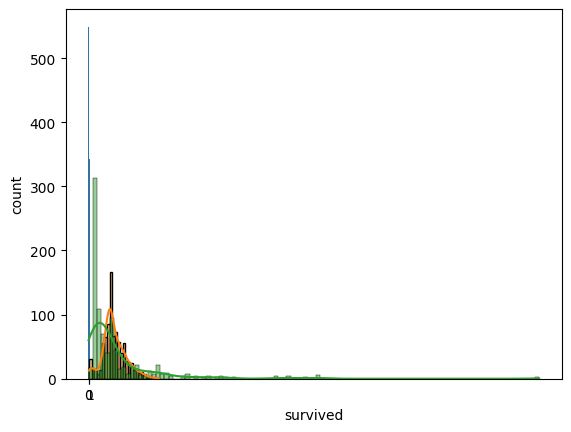

In [ ]:
sns.countplot(data=df_clean, x="survived")
sns.histplot(df_clean["age"], kde=True)
sns.histplot(df_clean["fare"], kde=True)

<Axes: >

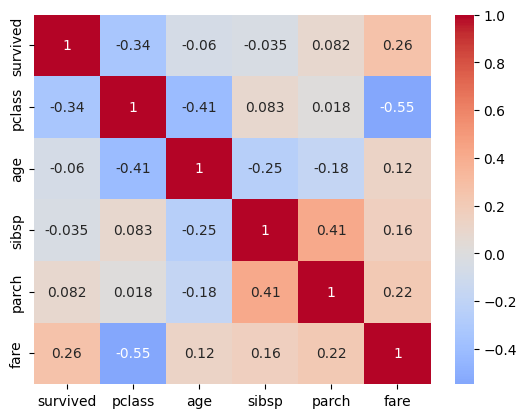

In [10]:
sns.barplot(data=df_clean, x="sex", y="survived", errorbar=None)
sns.barplot(data=df_clean, x="pclass", y="survived", errorbar=None)

corr = df_clean[["survived","pclass","age","sibsp","parch","fare"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)

<Axes: xlabel='family_size', ylabel='survived'>

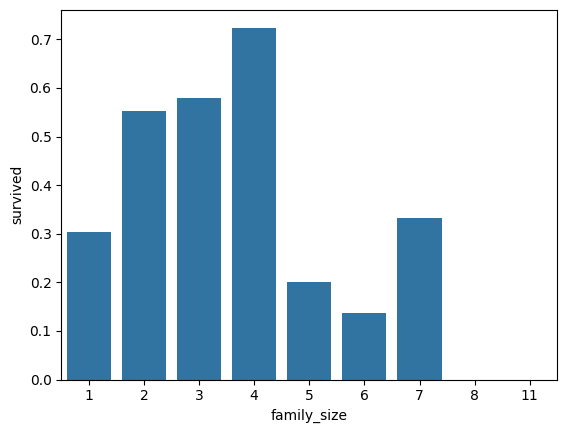

In [11]:
df_clean["family_size"] = df_clean["sibsp"] + df_clean["parch"] + 1
sns.barplot(data=df_clean, x="family_size", y="survived", errorbar=None)

In [12]:
q1, q3 = df_clean["fare"].quantile([0.25, 0.75])
upper = q3 + 1.5 * (q3 - q1)
outliers = df_clean[df_clean["fare"] > upper]

In [13]:
chi2, p_sex, _, _ = stats.chi2_contingency(pd.crosstab(df_clean["sex"], df_clean["survived"]))
chi2c, p_class, _, _ = stats.chi2_contingency(pd.crosstab(df_clean["pclass"], df_clean["survived"]))
t_stat, p_age = stats.ttest_ind(df_clean.loc[df_clean.survived==1,"age"], df_clean.loc[df_clean.survived==0,"age"], equal_var=False)